#### Sampling with DBM (W1)
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sampler, densities, helpers
import itertools
from IPython.display import clear_output

# Avoid messy output for Euler method.
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)

importlib.reload(sampler); importlib.reload(densities); importlib.reload(helpers);
sampler.hello()

Hello from the sampler file!


In [2]:
# NOTE Tweak as wanted.
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 11,
    
    "figure.figsize": (4, 3), 
    "figure.dpi": 150,
    
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.linewidth": 0.8,
    "axes.formatter.use_mathtext": True
})

In [3]:
# Longer compiling times - only use when finished.
plt.rcParams.update({"text.usetex": True})

---
---
---

1. Convergence of $N$-densities to the true equilibrium density $\rho(x)$.
See Li and Menon.

Compare quad-quartic ($x^2/2 + x^4/4$) and pure quartic ($x^4/4$) for $N = 6$ and $N = 30$ respectively. Files: `densities.py`.

In [12]:
"a" in "aaaaa"

True

In [44]:
# CALCULATE limiting and N-distributions.
importlib.reload(densities);
param_choices = [(6, "quad-quartic"), (30, "quad-quartic"), (6, "quartic"), (30, "quartic")]
# param_choices = [(6, "quadratic"), (30, "quadratic")]
grid = np.linspace(-2.5, 2.5, 500) 
K_Ns = []
rhos = []

def get_potential(type):
    if (type == "quad-quartic"):
        return lambda x: x**2/2 + x**4/4
    elif (type == "quartic"):
        return lambda x: x**4/4
    elif (type == "quadratic"):
        return lambda x: x**2/2
    else:
        raise ValueError(f"Potential {type} not found.")
    
for k, choices in enumerate(param_choices):
    N, pot_type = choices
    potential = get_potential(pot_type)

    # Same process as in paper, uses GS construction.
    pis, c_sqrs = densities.orthogonal_polys(N, potential, grid)
    K_N = densities.construct_kernel(N, potential, grid, pis, c_sqrs)

    q = 1 if ("quad" in pot_type) else 0
    g = 0 if (pot_type == "quadratic") else 1
    rho = densities.theoretical_density(grid, q = q, g = g)

    K_Ns.append(np.diag(K_N) / N) # Moved from the plotting part.
    rhos.append(rho)

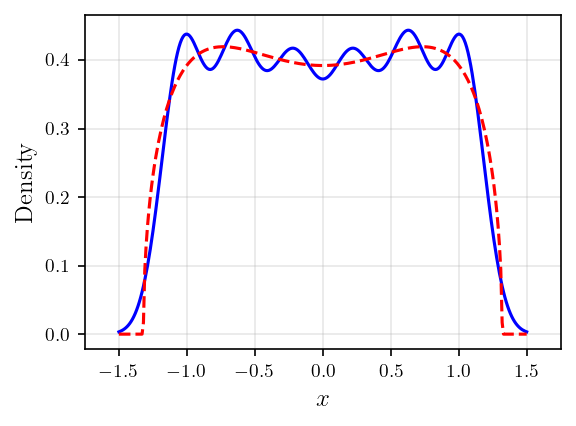

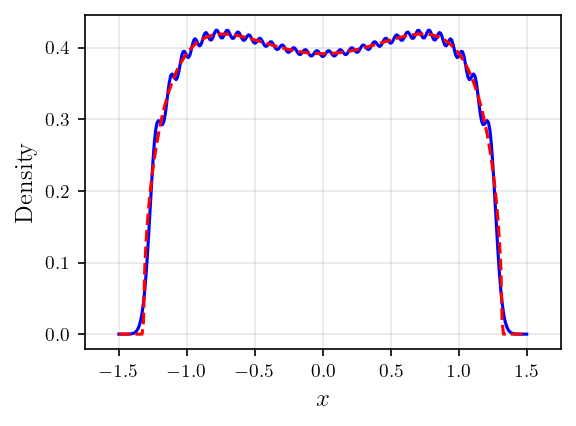

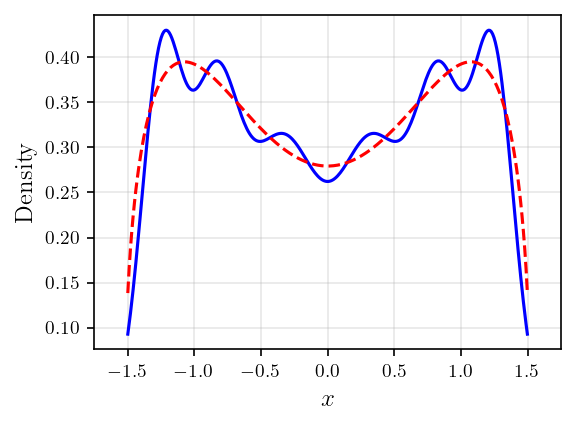

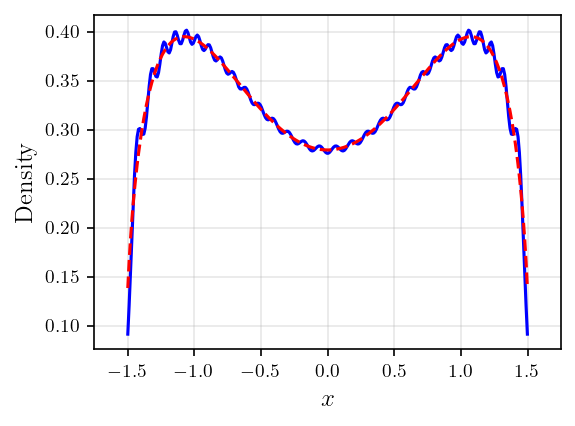

In [45]:
# PLOT limiting against N-distributions.
plot_names = ["A", "B", "C", "D"]
# plot_names = ["semicircle-A", "semicircle-B"]
for (K_N, rho, name) in zip(K_Ns, rhos, plot_names):
    # Clip grid to [-1.5, 1.5] to matchb resolution on paper.
    clip_range = 1.5 # Change if using semicircle.
    clipped_range = np.abs(grid) <= clip_range
    grid_clipped = grid[clipped_range]
    K_N_clipped = K_N[clipped_range]
    rho_clipped = rho[clipped_range]

    fig, ax = plt.subplots()
    ax.plot(grid_clipped, K_N_clipped, "b-", linewidth = 1.5, label = rf"Density $K_N(x)$.")
    ax.plot(grid_clipped, rho_clipped, "r--", linewidth = 1.5, label = rf"Limiting density $\rho(x)$.")

    # ax.set_title(rf"Convergence of $K_N(x)$ to $\rho(x)$: $N = $ {N}.")
    ax.set_xlabel('$x$');
    ax.set_ylabel('Density')
    ax.grid(True, alpha = 0.3)
    ax.set_xlim(-1*clip_range - 0.25, clip_range + 0.25)
    # ax.legend(loc = "best")

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/density-plot-{name}.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
    plt.close()

---

EXAMPLE PLOTS: Long-run sampling for large $N$ ($N = 500$ and $N = 1000$).

In [6]:
saved_data = np.load("data/long-simulations.npz")
results = saved_data["n500t10"][0]; results2 = saved_data["n1000t5"][0]

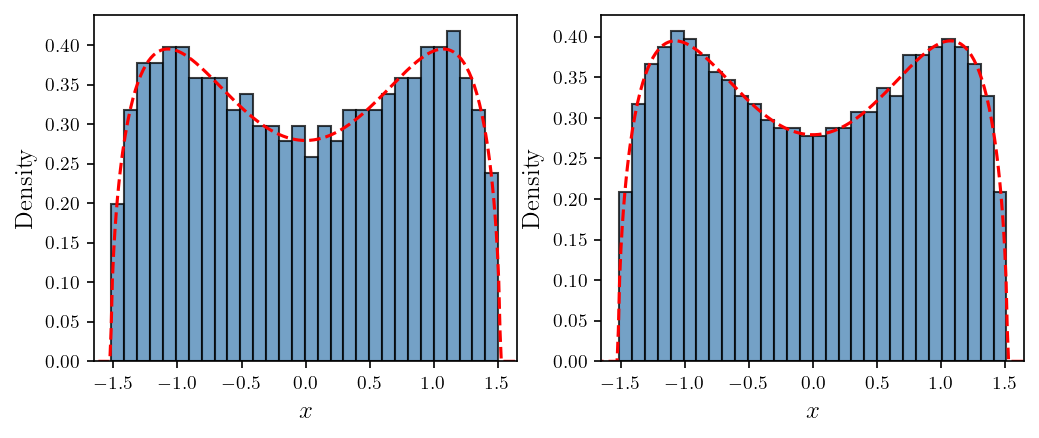

In [7]:
s_vals = np.linspace(-2.5, 2.5, 500)
density = densities.theoretical_density(s_vals, q = 0, g = 1)
fig1, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes

ax1.hist(results, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax1.plot(s_vals, density, 'r--')

# fig2, ax2 = plt.subplots()
ax2.hist(results2, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax2.plot(s_vals, density, "r--")

for ax in [ax1, ax2]:
    ax.set_xlim(-1.65, 1.65)
    ax.set_ylabel("Density")
    ax.set_xlabel(r"$x$")

# fig1.savefig("figures/implicit-long-run-hists-N500.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
# fig2.savefig("figures/implicit-long-run-hists-N1000.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")

plt.show()

---
---
---

Use the new `track_distance` parameter to compare decary of KS distance for the tamed scheme and the implicit scheme.
- Compare for maximum time $T = 8.0$ for $N = 20, 30, 50$ over $1000$ trials.
- Possibly run again for $N = 100$ in a separate instance, reload, combine, resave?

In [5]:
T = 8.0 
N_list = [20, 30, 50]
N_colours = {20: "orange", 30: "magenta", 50: "green", 100: "steelblue"}
num_trials_list = [1000]
methods = ["tamed", "implicit"]
results = {}

all_experiments = itertools.product(N_list, num_trials_list, methods)
for N, num_trials, method in all_experiments:
    dt = 1/(2*N) if (method == "implicit") else 1/(4*N**2)
    clear_output(wait = True)
    print(f"Running N = {N} for {method} method.")

    particles, times, distances = sampler.stochastic_sampler(N, T, dt, num_trials = num_trials, method = method, track_distance = True)
    results[(N, num_trials, method)] = {"times": times, "distances": distances, "particles": particles}

Running N = 50 for implicit method.


Over two hours to finish, see `data/ks-simulations.npz` and load as follows.

In [ ]:
archive = np.load("data/ks-simulations.npz")

results = {}
for key in archive.files:
    # Split the string back into its components
    # e.g., "20-1000-tamed_times" -> ["20", "1000", "tamed_times"]
    parts = key.split("-")
    N = int(parts[0])
    num_trials = int(parts[1])
    method, data_type = parts[2].rsplit("_", 1)
    
    dict_key = (N, num_trials, method)
    if dict_key not in results:
        results[dict_key] = {}
        
    results[dict_key][data_type] = archive[key]

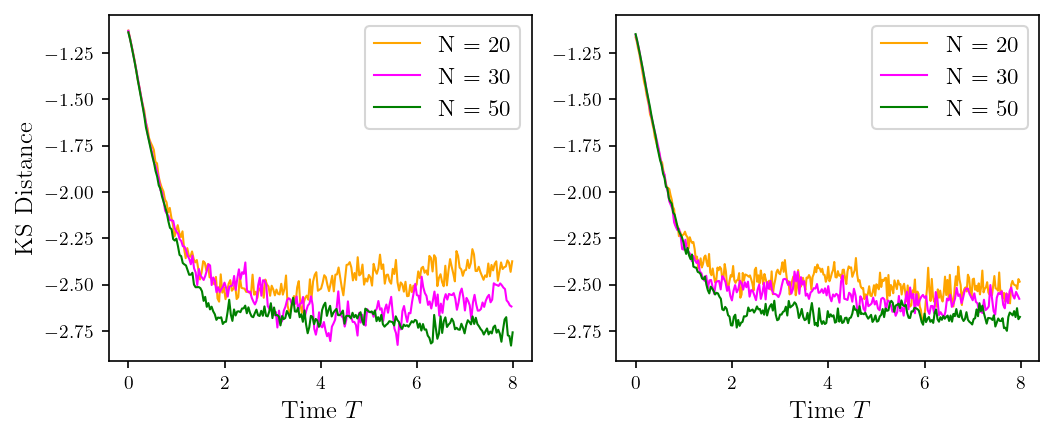

In [34]:
# PLOTTER for ks decay.
fixed_trials = 1000
fig, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes
# fig1, ax1 = plt.subplots(figsize = (4, 3))
# fig2, ax2 = plt.subplots(figsize = (4, 3))
# axes = [ax1, ax2]

for ax, method in zip(axes, methods):
    for N in N_list:
        key = (N, fixed_trials, method)
        data = results[key]
        
        ax.plot(data["times"], np.log10(data["distances"]), label = f"N = {N}", color = N_colours[N], lw = 1)

    ax.legend(loc = "upper right")
    # ax.set_title(method.capitalize())
    # ax.set_ylabel("KS Distance")
    ax.set_xlabel(r"Time $T$")

y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylabel("KS Distance")
for ax in axes:
    ax.set_ylim(y_min, y_max)

# fig1.savefig("figures/tamed-ks-decay-trials1000.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
# fig2.savefig("figures/implicit-ks-decay-trials1000.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
# Step size 1/2N and 1/4N^2. Pure quartic potential.
plt.show()